In [4]:
import requests
import pandas as pd
from io import StringIO

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0 Safari/537.36"
}

resp = requests.get(WIKI_URL, headers=headers, timeout=30)
resp.raise_for_status()

tables = pd.read_html(StringIO(resp.text))  # 不要直接传 URL

# 当前成分表（constituents）
constituents = None
for t in tables:
    cols = [str(c) for c in t.columns]
    if "Symbol" in cols and ("Security" in cols or "GICS Sector" in cols):
        constituents = t.copy()
        break

if constituents is None:
    raise RuntimeError("未找到 constituents 表")

constituents = constituents.rename(columns={"Symbol": "ticker", "Security": "name"})
constituents["ticker"] = constituents["ticker"].astype(str).str.strip()

# 变更表（Selected changes）
changes = None
for t in tables:
    if isinstance(t.columns, pd.MultiIndex):
        flat_cols = [" | ".join([str(x) for x in c if str(x) != "nan"]) for c in t.columns]
    else:
        flat_cols = [str(c) for c in t.columns]
    txt = " | ".join(flat_cols)
    if "Added" in txt and "Removed" in txt and "Date" in txt:
        changes = t.copy()

if changes is None:
    raise RuntimeError("未找到 changes 表")

print("Current constituents:", len(constituents))
print("Changes columns:", changes.columns)

Current constituents: 503
Changes columns: MultiIndex([('Effective Date', 'Effective Date'),
            (         'Added',         'Ticker'),
            (         'Added',       'Security'),
            (       'Removed',         'Ticker'),
            (       'Removed',       'Security'),
            (        'Reason',         'Reason')],
           )


In [5]:
import pandas as pd

def normalize_wiki_ticker(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x in ["", "nan", "None"]:
        return None
    return x

def wiki_to_yahoo_ticker(t):
    # Yahoo 常用 BRK-B / BF-B 这种格式
    if t is None or pd.isna(t):
        return t
    return str(t).strip().replace(".", "-")

chg = changes.copy()

# 展平 MultiIndex 列
if isinstance(chg.columns, pd.MultiIndex):
    chg.columns = [" | ".join([str(x) for x in c if str(x) != "nan"]).strip() for c in chg.columns]
else:
    chg.columns = [str(c) for c in chg.columns]

# 自动识别列名（Wikipedia 表头偶尔变）
date_col = [c for c in chg.columns if "Date" in c][0]
add_ticker_col = [c for c in chg.columns if "Added" in c and "Ticker" in c][0]
remove_ticker_col = [c for c in chg.columns if "Removed" in c and "Ticker" in c][0]

chg = chg[[date_col, add_ticker_col, remove_ticker_col]].copy()
chg.columns = ["date", "add_ticker", "remove_ticker"]
chg["date"] = pd.to_datetime(chg["date"], errors="coerce")
chg["add_ticker"] = chg["add_ticker"].map(normalize_wiki_ticker)
chg["remove_ticker"] = chg["remove_ticker"].map(normalize_wiki_ticker)
chg = chg.dropna(subset=["date"]).sort_values("date", ascending=False)

# 从“当前成分”倒推历史成分
current_set = set(constituents["ticker"].dropna().astype(str).str.strip())
cur = set(current_set)

# 构造月度快照：2015-01 到 2025-12（月末）
month_ends = pd.date_range("2015-01-31", "2025-12-31", freq="M")
month_ends = sorted(month_ends, reverse=True)

# 倒推时按 changes 从近到远推进
chg_iter = chg.itertuples(index=False)
chg_list = list(chg_iter)
j = 0

snapshots = []
for d in month_ends:
    # 把 > d 的变更倒推回去
    while j < len(chg_list) and pd.Timestamp(chg_list[j].date) > d:
        add_t = chg_list[j].add_ticker
        rem_t = chg_list[j].remove_ticker
        # 倒推逻辑：后来新增 -> 删掉；后来移除 -> 加回
        if add_t and add_t in cur:
            cur.remove(add_t)
        if rem_t:
            cur.add(rem_t)
        j += 1

    for t in sorted(cur):
        snapshots.append((d.normalize(), t, wiki_to_yahoo_ticker(t)))

membership_monthly = pd.DataFrame(snapshots, columns=["date", "ticker_wiki", "ticker"])
print(membership_monthly.head())
print(membership_monthly["date"].min(), membership_monthly["date"].max())
print("Rows:", len(membership_monthly))

/var/folders/c8/ptb00_8j39l6v030v2_yd41c0000gn/T/ipykernel_29386/2007012251.py:42: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_ends = pd.date_range("2015-01-31", "2025-12-31", freq="M")


        date ticker_wiki ticker
0 2025-12-31           A      A
1 2025-12-31        AAPL   AAPL
2 2025-12-31        ABBV   ABBV
3 2025-12-31        ABNB   ABNB
4 2025-12-31         ABT    ABT
2015-01-31 00:00:00 2025-12-31 00:00:00
Rows: 66736


In [6]:
import yfinance as yf
import pandas as pd
import time
from tqdm.auto import tqdm

all_tickers = sorted(membership_monthly["ticker"].dropna().unique().tolist())

def wide_to_long_yf(data_wide: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if not isinstance(data_wide.columns, pd.MultiIndex):
        out = data_wide.reset_index().copy()
        out.columns = [str(c).lower().replace(" ", "_") for c in out.columns]
        return out

    top_tickers = data_wide.columns.get_level_values(0).unique()
    for tk in top_tickers:
        sub = data_wide[tk].copy().reset_index()
        sub.columns = [str(c).lower().replace(" ", "_") for c in sub.columns]
        sub["ticker"] = tk
        rows.append(sub)

    out = pd.concat(rows, ignore_index=True)
    out = out.rename(columns={"adj close": "adj_close", "adj_close": "adj_close", "date": "date"})
    return out

batch_size = 50
parts = []

batch_starts = list(range(0, len(all_tickers), batch_size))

for i in tqdm(batch_starts, desc="Downloading batches", unit="batch"):
    batch = all_tickers[i:i+batch_size]
    data = yf.download(
        tickers=batch,
        start="2015-01-01",
        end="2026-01-01",
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        progress=False,   # 关闭 yfinance 自己的进度，避免和 tqdm 打架
        threads=True,
    )
    long_part = wide_to_long_yf(data)
    parts.append(long_part)
    time.sleep(0.5)

prices = pd.concat(parts, ignore_index=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()

lower_cols = {c.lower(): c for c in prices.columns}
sel = []
for c in ["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"]:
    if c in prices.columns:
        sel.append(c)
    elif c in lower_cols:
        sel.append(lower_cols[c])

prices = prices[sel].copy()
prices.columns = [str(c).lower() for c in prices.columns]

print(prices.head())
print(prices["date"].min(), prices["date"].max())

$ACE: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)
$ABMD: possibly delisted; no timezone found
$AGN: possibly delisted; no timezone found
$ADS: possibly delisted; no timezone found
$ALTR: possibly delisted; no timezone found
$ALXN: possibly delisted; no timezone found

6 Failed downloads:
['ACE']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)
['ABMD', 'AGN', 'ADS', 'ALTR', 'ALXN']: possibly delisted; no timezone found
$BCR: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)
$ANSS: possibly delisted; no timezone found
$ARG: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)
$ATVI: possibly delisted; no timezone found
$ARNC: possibly delisted; no timezone found
$APC: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1767243600")
$AVP: possibly delisted; no timezone found
$BHI: possibly delisted; no price data f

        date ticker  open  high  low  close  adj_close  volume
0 2015-01-02    ACE   NaN   NaN  NaN    NaN        NaN     NaN
1 2015-01-05    ACE   NaN   NaN  NaN    NaN        NaN     NaN
2 2015-01-06    ACE   NaN   NaN  NaN    NaN        NaN     NaN
3 2015-01-07    ACE   NaN   NaN  NaN    NaN        NaN     NaN
4 2015-01-08    ACE   NaN   NaN  NaN    NaN        NaN     NaN
2015-01-02 00:00:00 2025-12-31 00:00:00


In [9]:
prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()
prices["ticker"] = prices["ticker"].astype(str)

# 去重（有时同一 ticker/date 会重复）
prices = prices.drop_duplicates(subset=["date", "ticker"], keep="last")

# 设为 MultiIndex panel: [date, ticker]
panel = (
    prices
    .set_index(["date", "ticker"])
    .sort_index()
)

In [10]:
panel

open        high         low       close   adj_close  \
date       ticker                                                               
2015-01-02 A        41.180000   41.310001   40.369999   40.560001   37.054718   
           AA       38.135609   38.399940   37.655010   38.159641   35.572784   
           AAL      54.279999   54.599998   53.070000   53.910000   51.079910   
           AAP     160.850006  162.500000  157.470001  158.559998  138.632584   
           AAPL     27.847500   27.860001   26.837500   27.332500   24.214891   
...                       ...         ...         ...         ...         ...   
2025-12-31 YUM     151.750000  152.350006  151.110001  151.279999  150.585968   
           ZBH      90.610001   90.830002   89.820000   89.919998   89.919998   
           ZBRA    246.779999  246.960007  242.639999  242.820007  242.820007   
           ZION     58.889999   58.990002   58.310001   58.540001   58.121258   
           ZTS     126.040001  126.839996  125.769997  125.820000  125.285027   

                        volume  
date       ticker               
2015-01-02 A         1529200.0  
           AA        4340408.0  
           AAL      10748600.0  
           AAP        509800.0  
           AAPL    212818400.0  
...                        ...  
2025-12-31 YUM       1102500.0  
           ZBH       1013900.0  
           ZBRA       376600.0  
           ZION      1129000.0  
           ZTS       2943300.0  

[2005350 rows x 6 columns]

In [11]:
import pandas as pd
import numpy as np

def backtest_gapdown_intraday(
    panel: pd.DataFrame,
    top_n: int = 10,
    vol_lookback: int = 90,
    ma_lookback: int = 20,
    use_adj_close_for_signals: bool = False,
):
    """
    panel: MultiIndex [date, ticker], columns include open/high/low/close
    returns:
      daily_port_ret: Series (date -> portfolio return)
      picks: DataFrame (selected stocks each day with signal values)
      feats: DataFrame (all computed features, optional for debugging)
    """
    df = panel.copy().sort_index()

    # 确保索引顺序正确
    if df.index.names != ["date", "ticker"]:
        df = df.copy()
        df.index = df.index.set_names(["date", "ticker"])

    # 转成长表便于 groupby('ticker') 做 rolling
    df = df.reset_index().sort_values(["ticker", "date"]).copy()

    px_close = "adj_close" if (use_adj_close_for_signals and "adj_close" in df.columns) else "close"

    # 1) 前一日 low
    df["prev_low"] = df.groupby("ticker")["low"].shift(1)

    # 2) 前一日 close（用于 close-to-close return）
    df["prev_close"] = df.groupby("ticker")[px_close].shift(1)

    # 3) close-to-close returns
    df["cc_ret"] = df.groupby("ticker")[px_close].pct_change()

    # 4) 90日 rolling std（用到 t-1 为止，所以再 shift(1)）
    df["sigma90"] = (
        df.groupby("ticker")["cc_ret"]
          .rolling(vol_lookback, min_periods=vol_lookback)
          .std()
          .reset_index(level=0, drop=True)
    )
    # sigma90 已经是基于历史序列到当日位置的rolling结果，
    # 为避免使用当日 close 信息，策略在开盘决策时应使用昨日可得sigma:
    df["sigma90"] = df.groupby("ticker")["sigma90"].shift(1)

    # 5) gap return: from prev day's low to today's open
    df["gap_from_prev_low"] = df["open"] / df["prev_low"] - 1

    # 6) 20日均线（基于 close，且只用到前一日）
    df["ma20"] = (
        df.groupby("ticker")[px_close]
          .rolling(ma_lookback, min_periods=ma_lookback)
          .mean()
          .reset_index(level=0, drop=True)
    )
    df["ma20"] = df.groupby("ticker")["ma20"].shift(1)

    # 7) 过滤条件
    cond_gapdown = df["gap_from_prev_low"] < (-df["sigma90"])
    cond_ma = df["open"] > df["ma20"]

    df["eligible"] = cond_gapdown & cond_ma

    # 8) 当日开盘买入到收盘卖出收益
    df["intra_ret"] = df["close"] / df["open"] - 1

    # 去掉关键字段缺失
    df_valid = df.dropna(subset=["prev_low", "sigma90", "ma20", "intra_ret"]).copy()

    # 9) 每天选 top_n 个 gap 最低的（最“超跌”）
    elig = df_valid[df_valid["eligible"]].copy()

    # 按日期内 gap 升序排名
    elig["rank"] = elig.groupby("date")["gap_from_prev_low"].rank(method="first", ascending=True)
    picks = elig[elig["rank"] <= top_n].copy()

    # 10) 等权组合日收益
    daily_port_ret = picks.groupby("date")["intra_ret"].mean().sort_index()

    # 可选：输出一些统计
    daily_count = picks.groupby("date")["ticker"].nunique().rename("n_picks")
    daily_port_ret = daily_port_ret.to_frame("port_ret").join(daily_count, how="left")
    daily_port_ret["n_picks"] = daily_port_ret["n_picks"].fillna(0).astype(int)

    # 恢复 feature 表为 MultiIndex（方便你排查）
    feats = df_valid.set_index(["date", "ticker"]).sort_index()

    return daily_port_ret, picks, feats

In [12]:
daily_port, picks, feats = backtest_gapdown_intraday(panel)

print(daily_port.head())
print(daily_port["port_ret"].describe())

/var/folders/c8/ptb00_8j39l6v030v2_yd41c0000gn/T/ipykernel_29386/2709398184.py:37: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["cc_ret"] = df.groupby("ticker")[px_close].pct_change()


            port_ret  n_picks
date                         
2015-05-15 -0.036845        1
2015-05-20  0.007300        1
2015-05-21  0.024558        2
2015-06-11  0.013830        1
2015-06-12  0.019739        1
count    914.000000
mean       0.003222
std        0.029225
min       -0.360614
25%       -0.009297
50%        0.002214
75%        0.015685
max        0.206837
Name: port_ret, dtype: float64


In [13]:
import matplotlib.pyplot as plt

# daily_port 是前面 backtest 返回的 DataFrame，包含列: port_ret
ret = daily_port["port_ret"].dropna().sort_index()

# 累计净值（初始资金=1）
equity = (1 + ret).cumprod()

# 累计收益率（初始=0）
cumret = equity - 1

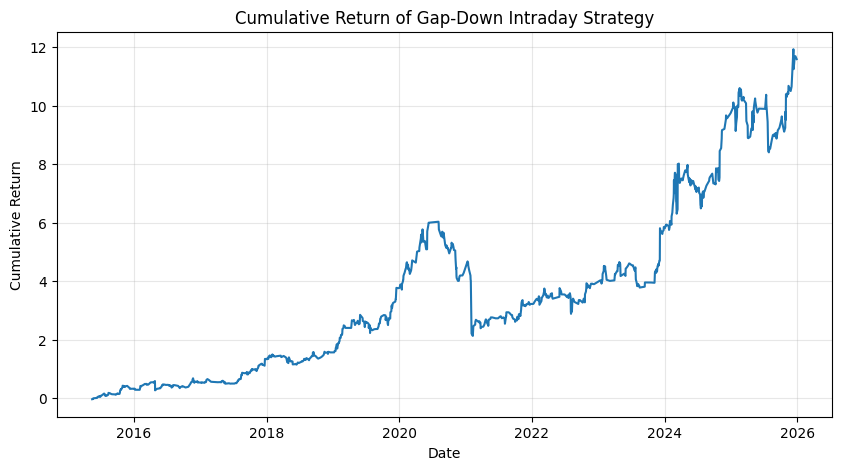

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(cumret.index, cumret.values)
plt.title("Cumulative Return of Gap-Down Intraday Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
!pip install akshare

  Using cached akshare-1.18.30-py3-none-any.whl.metadata (13 kB)
  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached jsonpath-0.82.2-py3-none-any.whl
  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
  Using cached mini_racer-0.14.1-py3-none-macosx_10_9_x86_64.whl.metadata (22 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached akshare-1.18.30-py3-none-any.whl (1.1 MB)
Using cached mini_racer-0.14.1-py3-none-macosx_10_9_x86_64.whl (20.0 MB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [akshare]m6/7 [akshare]]r]


In [3]:
import akshare as ak

ak.option_finance_board(symbol="华泰柏瑞沪深300ETF期权", end_month="2212")


ValueError: Length mismatch: Expected axis has 0 elements, new values have 5 elements